<a href="https://colab.research.google.com/github/adamqureshiaq-ui/Premier-League-Prediction-Model-/blob/main/Premier_League_Match_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
urls = {
    "2022_23": "https://football-data.co.uk/mmz4281/2223/E0.csv",
    "2023_24": "https://football-data.co.uk/mmz4281/2324/E0.csv",
    "2024_25": "https://football-data.co.uk/mmz4281/2425/E0.csv",
    "2025_26": "https://football-data.co.uk/mmz4281/2526/E0.csv",
    "2026_27": "https://football-data.co.uk/mmz4281/2627/E0.csv"
}

dfs = []

for season, url in urls.items():
    df_season = pd.read_csv(url)
    df_season["Season"] = season   # add season label
    dfs.append(df_season)

# Combine all seasons
df_all = pd.concat(dfs, ignore_index=True)


In [ ]:
df_all

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,PPA,SKBH,SKBD,SKBA,PPCH,PPCD,PPCA,SKBCH,SKBCD,SKBCA
0,E0,05/08/2022,20:00,Crystal Palace,Arsenal,0,2,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,06/08/2022,12:30,Fulham,Liverpool,2,2,D,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,06/08/2022,15:00,Bournemouth,Aston Villa,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,06/08/2022,15:00,Leeds,Wolves,2,1,H,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,06/08/2022,15:00,Newcastle,Nott'm Forest,2,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1545,E0,05/09/2026,15:00,Man City,Coventry,1,0,H,1,0,...,15.00,1.14,7.5,13.00,1.17,7.50,14.00,1.17,8.0,13.00
1546,E0,05/09/2026,15:00,Nott'm Forest,Tottenham,0,0,D,0,0,...,2.88,2.38,3.3,2.88,2.63,3.25,2.63,2.63,3.3,2.63
1547,E0,05/09/2026,17:30,Hull,Aston Villa,0,0,D,0,0,...,1.85,3.90,3.6,1.85,3.80,3.60,1.90,3.80,3.7,1.90
1548,E0,06/09/2026,14:00,Everton,Man United,2,2,D,0,0,...,2.10,3.25,3.5,2.10,3.60,3.75,1.91,3.60,3.8,1.91


In [ ]:
df_all["Date"] = pd.to_datetime(df_all["Date"], dayfirst=True, errors="coerce")

df_all.columns = (
    df_all.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
)

core_cols = [
    "Season", "Date", "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR",
    "HTHG", "HTAG", "HTR",
    "HS", "AS", "HST", "AST",
    "HC", "AC", "HF", "AF",
    "HY", "AY", "HR", "AR",
    "AvgH", "AvgD", "AvgA",  # market average odds
]

df_all = df_all[core_cols]

In [ ]:
df_all["FTR"] = df_all["FTR"].str.upper().str.strip()

numeric_cols = df_all.select_dtypes(include=["float64", "int64"]).columns
df_all[numeric_cols] = df_all[numeric_cols].fillna(0)

df_all = df_all.sort_values("Date").reset_index(drop=True)

/tmp/ipykernel_658/3724698436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["FTR"] = df_all["FTR"].str.upper().str.strip()
/tmp/ipykernel_658/3724698436.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all[numeric_cols] = df_all[numeric_cols].fillna(0)


In [ ]:
numeric_cols = df_all.select_dtypes(include=["float64", "int64"]).columns
df_all.loc[:, numeric_cols] = df_all[numeric_cols].fillna(0)


In [ ]:
df_all

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AC,HF,AF,HY,AY,HR,AR,AvgH,AvgD,AvgA
0,2022_23,2022-08-05,Crystal Palace,Arsenal,0,2,A,0,1,A,...,5,16,11,1,2,0,0,4.39,3.59,1.88
1,2022_23,2022-08-06,Fulham,Liverpool,2,2,D,1,0,H,...,4,7,9,2,0,0,0,10.99,6.05,1.28
2,2022_23,2022-08-06,Bournemouth,Aston Villa,2,0,H,1,0,H,...,5,18,16,3,3,0,0,3.80,3.50,2.04
3,2022_23,2022-08-06,Leeds,Wolves,2,1,H,1,1,D,...,4,13,9,2,0,0,0,2.34,3.34,3.18
4,2022_23,2022-08-06,Newcastle,Nott'm Forest,2,0,H,0,0,D,...,1,9,14,0,3,0,0,1.67,3.80,5.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1545,2026_27,2026-09-05,Newcastle,Bournemouth,2,2,D,1,2,A,...,3,19,17,2,3,0,0,2.10,3.64,3.19
1546,2026_27,2026-09-05,Brighton,Leeds,1,1,D,0,1,A,...,6,13,16,3,3,0,0,1.98,3.52,3.68
1547,2026_27,2026-09-05,Hull,Aston Villa,0,0,D,0,0,D,...,4,10,5,2,0,0,0,4.04,3.62,1.86
1548,2026_27,2026-09-06,Everton,Man United,2,2,D,0,0,D,...,3,7,11,3,3,0,0,3.21,3.54,2.12


In [ ]:
START_ELO = 1500
K = 30
HOME_ADVANTAGE = 70

df_all = df_all.sort_values("Date").reset_index(drop=True)

teams = pd.unique(df_all[["HomeTeam", "AwayTeam"]].values.ravel())
elo = {team: START_ELO for team in teams}

df_all["HomeElo"] = np.nan
df_all["AwayElo"] = np.nan
df_all["EloDiff"] = np.nan

season_weights = {
    "2026_27": 1.0,
    "2025_26": 1.0,
    "2024_25": 0.7,
    "2023_24": 0.4,
    "2022_23": 0.3
}


for idx, row in df_all.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_elo = elo[home]
    away_elo = elo[away]

    df_all.loc[idx, "HomeElo"] = home_elo
    df_all.loc[idx, "AwayElo"] = away_elo
    df_all.loc[idx, "EloDiff"] = home_elo - away_elo

    exp_home = 1 / (1 + 10 ** ((away_elo - home_elo - HOME_ADVANTAGE) / 400))
    exp_away = 1 - exp_home

    if row["FTR"] == "H":
        score_home, score_away = 1, 0
    elif row["FTR"] == "A":
        score_home, score_away = 0, 1
    else:
        score_home, score_away = 0.5, 0.5

    weight = season_weights[row["Season"]]

    new_home_elo = home_elo + (K * weight) * (score_home - exp_home)
    new_away_elo = away_elo + (K * weight) * (score_away - exp_away)

    elo[home] = new_home_elo
    elo[away] = new_away_elo


In [ ]:
print(teams)

['Crystal Palace' 'Arsenal' 'Fulham' 'Liverpool' 'Bournemouth'
 'Aston Villa' 'Leeds' 'Wolves' 'Newcastle' "Nott'm Forest" 'Tottenham'
 'Southampton' 'Everton' 'Chelsea' 'Leicester' 'Brentford' 'Man United'
 'Brighton' 'West Ham' 'Man City' 'Burnley' 'Luton' 'Sheffield United'
 'Ipswich' 'Sunderland' 'Coventry' 'Hull']


In [ ]:
import matplotlib.pyplot as plt

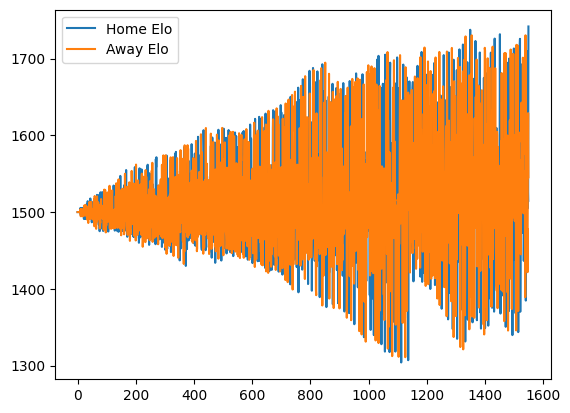

In [ ]:
plt.plot(df_all["HomeElo"], label="Home Elo")
plt.plot(df_all["AwayElo"], label="Away Elo")
plt.legend()

In [ ]:
# Convert final Elo dictionary → DataFrame
elo_table = (
    pd.DataFrame.from_dict(elo, orient="index", columns=["FinalElo"])
      .reset_index()
      .rename(columns={"index": "Team"})
      .sort_values("FinalElo", ascending=False)
)

elo_table


,Team,FinalElo
1,Arsenal,1747.145157
19,Man City,1714.260347
16,Man United,1626.959867
4,Bournemouth,1588.517902
3,Liverpool,1585.123460
5,Aston Villa,1567.333135
15,Brentford,1546.446733
6,Leeds,1540.683569
13,Chelsea,1540.048731
17,Brighton,1536.691313


/tmp/ipykernel_658/3410872025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


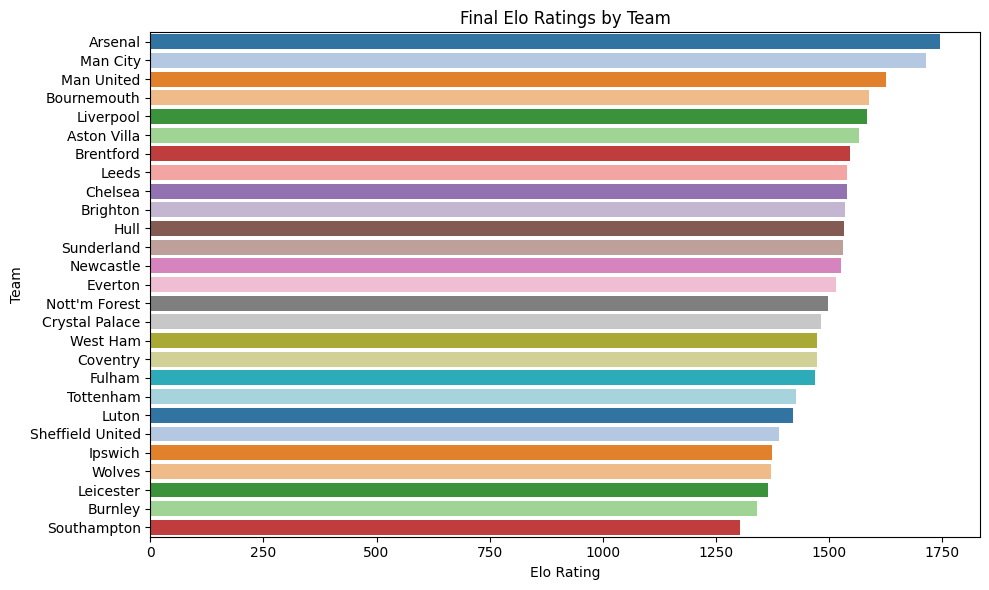

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    data=elo_table,
    x="FinalElo",
    y="Team",
    palette="tab20"
)

plt.title("Final Elo Ratings by Team")
plt.xlabel("Elo Rating")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


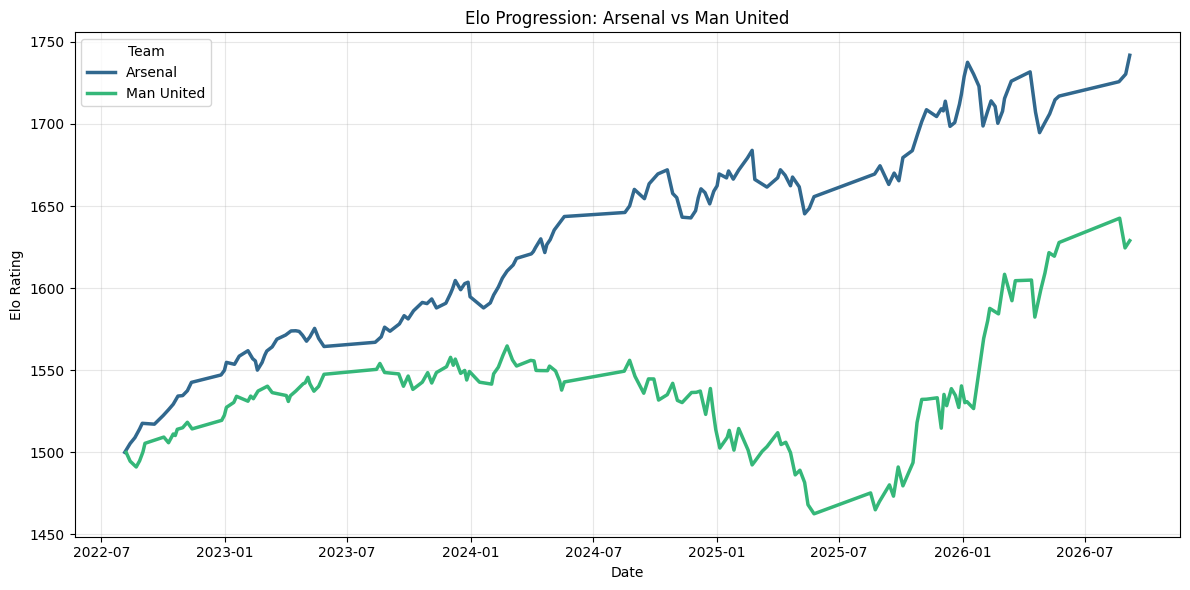

In [ ]:
teams_to_plot = ["Arsenal", "Man United"]

df_plot = df_all[df_all["HomeTeam"].isin(teams_to_plot) |
                 df_all["AwayTeam"].isin(teams_to_plot)].copy()

df_plot["Team"] = df_plot.apply(
    lambda row: row["HomeTeam"] if row["HomeTeam"] in teams_to_plot
                else row["AwayTeam"],
    axis=1
)

df_plot["TeamElo"] = df_plot.apply(
    lambda row: row["HomeElo"] if row["Team"] == row["HomeTeam"]
                else row["AwayElo"],
    axis=1
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_plot,
    x="Date",
    y="TeamElo",
    hue="Team",
    palette="viridis",
    linewidth=2.5
)

team_names = " vs ".join(teams_to_plot)
plt.title(f"Elo Progression: {team_names}")

plt.xlabel("Date")
plt.ylabel("Elo Rating")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df_all

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,AvgH,AvgD,AvgA,HomeElo,AwayElo,EloDiff
0,2022_23,2022-08-05,Crystal Palace,Arsenal,0,2,A,0,1,A,...,1,2,0,0,4.39,3.59,1.88,1500.000000,1500.000000,0.000000
1,2022_23,2022-08-06,Fulham,Liverpool,2,2,D,1,0,H,...,2,0,0,0,10.99,6.05,1.28,1500.000000,1500.000000,0.000000
2,2022_23,2022-08-06,Bournemouth,Aston Villa,2,0,H,1,0,H,...,3,3,0,0,3.80,3.50,2.04,1500.000000,1500.000000,0.000000
3,2022_23,2022-08-06,Leeds,Wolves,2,1,H,1,1,D,...,2,0,0,0,2.34,3.34,3.18,1500.000000,1500.000000,0.000000
4,2022_23,2022-08-06,Newcastle,Nott'm Forest,2,0,H,0,0,D,...,0,3,0,0,1.67,3.80,5.57,1500.000000,1500.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1545,2026_27,2026-09-05,Man City,Coventry,1,0,H,1,0,H,...,1,2,0,0,1.17,7.64,13.85,1709.762218,1478.346146,231.416072
1546,2026_27,2026-09-05,Nott'm Forest,Tottenham,0,0,D,0,0,D,...,2,2,0,0,2.40,3.36,2.86,1504.681300,1421.734983,82.946318
1547,2026_27,2026-09-05,Hull,Aston Villa,0,0,D,0,0,D,...,2,0,0,0,4.04,3.62,1.86,1535.118121,1565.635848,-30.517728
1548,2026_27,2026-09-06,Everton,Man United,2,2,D,0,0,D,...,3,3,0,0,3.21,3.54,2.12,1513.444320,1628.911723,-115.467403


In [ ]:
# Build one long-format table for all team-level stats
df_long = pd.DataFrame({
    "Date": pd.concat([df_all["Date"], df_all["Date"]]),
    "Team": pd.concat([df_all["HomeTeam"], df_all["AwayTeam"]]),
    "GoalsFor": pd.concat([df_all["FTHG"], df_all["FTAG"]]),
    "GoalsAgainst": pd.concat([df_all["FTAG"], df_all["FTHG"]]),
    "ShotsFor": pd.concat([df_all["HS"], df_all["AS"]]),
    "ShotsAgainst": pd.concat([df_all["AS"], df_all["HS"]])
})

# Sort by team + date (critical for rolling windows)
df_long = df_long.sort_values(["Team", "Date"])



In [ ]:
# Rolling window size
window = 5

# --- Shift first to avoid leakage ---
df_long["GF_shift"] = df_long.groupby("Team")["GoalsFor"].shift(1)
df_long["GA_shift"] = df_long.groupby("Team")["GoalsAgainst"].shift(1)
df_long["SF_shift"] = df_long.groupby("Team")["ShotsFor"].shift(1)
df_long["SA_shift"] = df_long.groupby("Team")["ShotsAgainst"].shift(1)

# --- Rolling features using ONLY past matches ---
df_long["Roll_GF"] = (
    df_long.groupby("Team")["GF_shift"]
           .rolling(window)
           .mean()
           .reset_index(0, drop=True)
)

df_long["Roll_GA"] = (
    df_long.groupby("Team")["GA_shift"]
           .rolling(window)
           .mean()
           .reset_index(0, drop=True)
)

df_long["Roll_SF"] = (
    df_long.groupby("Team")["SF_shift"]
           .rolling(window)
           .mean()
           .reset_index(0, drop=True)
)

df_long["Roll_SA"] = (
    df_long.groupby("Team")["SA_shift"]
           .rolling(window)
           .mean()
           .reset_index(0, drop=True)
)


# Merge back into main dataset (home + away)
df_all = df_all.merge(
    df_long,
    left_on=["Date", "HomeTeam"],
    right_on=["Date", "Team"],
    how="left",
    suffixes=("", "_Home")
)

df_all = df_all.merge(
    df_long,
    left_on=["Date", "AwayTeam"],
    right_on=["Date", "Team"],
    how="left",
    suffixes=("", "_Away")
)


In [ ]:
# Convert averaged odds to raw implied probabilities
df_all["Prob_H_raw"] = 1 / df_all["AvgH"]
df_all["Prob_D_raw"] = 1 / df_all["AvgD"]
df_all["Prob_A_raw"] = 1 / df_all["AvgA"]

# Sum of raw probabilities (includes bookmaker margin)
total_raw = df_all["Prob_H_raw"] + df_all["Prob_D_raw"] + df_all["Prob_A_raw"]

# Normalise to remove margin
df_all["Prob_H"] = df_all["Prob_H_raw"] / total_raw
df_all["Prob_D"] = df_all["Prob_D_raw"] / total_raw
df_all["Prob_A"] = df_all["Prob_A_raw"] / total_raw


In [ ]:
(df_all["Prob_H"] + df_all["Prob_D"] + df_all["Prob_A"]).head()



,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [ ]:
# --- Market Expected Points ---
df_all["MarketExpPts_H"] = 3 * df_all["Prob_H"] + 1 * df_all["Prob_D"]
df_all["MarketExpPts_A"] = 3 * df_all["Prob_A"] + 1 * df_all["Prob_D"]

# --- Market Win Strength (relative win probability) ---
df_all["MarketWinStrength"] = df_all["Prob_H"] - df_all["Prob_A"]

# --- Market Draw Strength ---
df_all["MarketDrawStrength"] = df_all["Prob_D"]

# --- Odds Ratios (relative strength of outcomes) ---
df_all["OddsRatio_HA"] = df_all["AvgA"] / df_all["AvgH"]
df_all["OddsRatio_HD"] = df_all["AvgD"] / df_all["AvgH"]
df_all["OddsRatio_AD"] = df_all["AvgD"] / df_all["AvgA"]



In [ ]:
# Step 6 — Target Engineering (H/D/A Classification)
df_all["Target"] = df_all["FTR"]   # Full Time Result: 'H', 'D', 'A'


In [ ]:
df_all.columns

Index(['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY',
       'AY', 'HR', 'AR', 'AvgH', 'AvgD', 'AvgA', 'HomeElo', 'AwayElo',
       'EloDiff', 'Team', 'GoalsFor', 'GoalsAgainst', 'ShotsFor',
       'ShotsAgainst', 'GF_shift', 'GA_shift', 'SF_shift', 'SA_shift',
       'Roll_GF', 'Roll_GA', 'Roll_SF', 'Roll_SA', 'Team_Away',
       'GoalsFor_Away', 'GoalsAgainst_Away', 'ShotsFor_Away',
       'ShotsAgainst_Away', 'GF_shift_Away', 'GA_shift_Away', 'SF_shift_Away',
       'SA_shift_Away', 'Roll_GF_Away', 'Roll_GA_Away', 'Roll_SF_Away',
       'Roll_SA_Away', 'Prob_H_raw', 'Prob_D_raw', 'Prob_A_raw', 'Prob_H',
       'Prob_D', 'Prob_A', 'MarketExpPts_H', 'MarketExpPts_A',
       'MarketWinStrength', 'MarketDrawStrength', 'OddsRatio_HA',
       'OddsRatio_HD', 'OddsRatio_AD', 'Target'],
      dtype='object')

In [ ]:
# -----------------------------------------
# Step 7 — Build Modelling Dataset (Leak‑Proof)
# -----------------------------------------

from sklearn.preprocessing import LabelEncoder

# 1. Encode categorical variables (teams + target)
le_team = LabelEncoder()
df_all["HomeTeam_enc"] = le_team.fit_transform(df_all["HomeTeam"])
df_all["AwayTeam_enc"] = le_team.fit_transform(df_all["AwayTeam"])

le_target = LabelEncoder()
df_all["Target_enc"] = le_target.fit_transform(df_all["Target"])   # H/D/A → 0/1/2


# 2. Select final feature list
feature_list = [
    # Rolling form features (home/away)
    "Roll_GF", "Roll_GA", "Roll_SF", "Roll_SA",
    "Roll_GF_Away", "Roll_GA_Away", "Roll_SF_Away", "Roll_SA_Away",

    # Market probabilities
    "Prob_H", "Prob_D", "Prob_A",

    # Market strength features
    "MarketExpPts_H", "MarketExpPts_A",
    "MarketWinStrength",
    "MarketDrawStrength",

    # Odds ratios
    "OddsRatio_HA", "OddsRatio_HD", "OddsRatio_AD",

    # Elo features
    "HomeElo", "AwayElo", "EloDiff",

    # Encoded categorical
    "HomeTeam_enc", "AwayTeam_enc"
]


# 3. Handle missing values (median fill)
df_all[feature_list] = df_all[feature_list].fillna(df_all[feature_list].median())


# 4. Chronological train/test split (NO SHUFFLE)
df_all = df_all.sort_values("Date").reset_index(drop=True)

split_index = int(len(df_all) * 0.8)

train_df = df_all.iloc[:split_index]
test_df  = df_all.iloc[split_index:]


# 5. Build final modelling matrices
X_train = train_df[feature_list]
y_train = train_df["Target_enc"]

X_test  = test_df[feature_list]
y_test  = test_df["Target_enc"]


In [ ]:
# ---------------------------------------------------------
# Train XGBoost with early stopping (native API)
# ---------------------------------------------------------

import xgboost as xgb

# 1. Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# 2. Set parameters
params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",

    # Regularisation
    "learning_rate": 0.03,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.5,
    "reg_lambda": 1.0,
    "min_child_weight": 3,
    "gamma": 2,
}

# 3. Train with early stopping
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtest, "validation")],
    early_stopping_rounds=50
)

# 4. Predict probabilities
y_pred_proba = model.predict(dtest)


[0]	validation-mlogloss:1.10062
[1]	validation-mlogloss:1.09706
[2]	validation-mlogloss:1.09388
[3]	validation-mlogloss:1.09049
[4]	validation-mlogloss:1.08772
[5]	validation-mlogloss:1.08548
[6]	validation-mlogloss:1.08302
[7]	validation-mlogloss:1.08047
[8]	validation-mlogloss:1.07891
[9]	validation-mlogloss:1.07642
[10]	validation-mlogloss:1.07467
[11]	validation-mlogloss:1.07244
[12]	validation-mlogloss:1.07036
[13]	validation-mlogloss:1.06878
[14]	validation-mlogloss:1.06691
[15]	validation-mlogloss:1.06526
[16]	validation-mlogloss:1.06324
[17]	validation-mlogloss:1.06151
[18]	validation-mlogloss:1.06017
[19]	validation-mlogloss:1.05875
[20]	validation-mlogloss:1.05673
[21]	validation-mlogloss:1.05525
[22]	validation-mlogloss:1.05406
[23]	validation-mlogloss:1.05298
[24]	validation-mlogloss:1.05159
[25]	validation-mlogloss:1.05053
[26]	validation-mlogloss:1.04967
[27]	validation-mlogloss:1.04918
[28]	validation-mlogloss:1.04830
[29]	validation-mlogloss:1.04716
[30]	validation-mlog

In [ ]:
import numpy as np
from sklearn.metrics import log_loss, accuracy_score

# y_pred_proba is already calculated in the previous cell as model.predict(dtest)

logloss = log_loss(y_test, y_pred_proba)
acc = accuracy_score(y_test, np.argmax(y_pred_proba, axis=1))

print("Log Loss:", logloss)
print("Accuracy:", acc)

Log Loss: 1.035542759500856
Accuracy: 0.4838709677419355


In [ ]:
# ---------------------------------------------------------
# Predict Man United vs Man City (Sunday 16:30)
# ---------------------------------------------------------

import pandas as pd
import xgboost as xgb

# 1. Create base fixture row
new_match = {
    "Season": "2026/2027",
    "Date": pd.to_datetime("2026-09-13"),
    "HomeTeam": "Man United",
    "AwayTeam": "Man City",
}

# 2. Insert market probabilities
new_match["Prob_H"] = 0.304
new_match["Prob_D"] = 0.254
new_match["Prob_A"] = 0.442

# Convert probabilities → odds
new_match["AvgH"] = 1 / new_match["Prob_H"]
new_match["AvgD"] = 1 / new_match["Prob_D"]
new_match["AvgA"] = 1 / new_match["Prob_A"]

# 3. Get latest rolling features
home_row = df_all[df_all["Team"] == "Man United"].iloc[-1]
away_row = df_all[df_all["Team"] == "Man City"].iloc[-1]

new_match["Roll_GF"] = home_row["Roll_GF"]
new_match["Roll_GA"] = home_row["Roll_GA"]
new_match["Roll_SF"] = home_row["Roll_SF"]
new_match["Roll_SA"] = home_row["Roll_SA"]

new_match["Roll_GF_Away"] = away_row["Roll_GF"]
new_match["Roll_GA_Away"] = away_row["Roll_GA"]
new_match["Roll_SF_Away"] = away_row["Roll_SF"]
new_match["Roll_SA_Away"] = away_row["Roll_SA"]

# 4. Market features
new_match["MarketExpPts_H"] = 3 * new_match["Prob_H"] + 1 * new_match["Prob_D"]
new_match["MarketExpPts_A"] = 3 * new_match["Prob_A"] + 1 * new_match["Prob_D"]
new_match["MarketWinStrength"] = new_match["Prob_H"] - new_match["Prob_A"]
new_match["MarketDrawStrength"] = new_match["Prob_D"]
new_match["OddsRatio_HA"] = new_match["Prob_H"] / new_match["Prob_A"]
new_match["OddsRatio_HD"] = new_match["Prob_H"] / new_match["Prob_D"]
new_match["OddsRatio_AD"] = new_match["Prob_A"] / new_match["Prob_D"]

# 5. Elo features
new_match["HomeElo"] = home_row["HomeElo"]
new_match["AwayElo"] = away_row["AwayElo"]
new_match["EloDiff"] = home_row["HomeElo"] - away_row["AwayElo"]

# 6. Encode teams
new_match["HomeTeam_enc"] = le_team.transform(["Man United"])[0]
new_match["AwayTeam_enc"] = le_team.transform(["Man City"])[0]

# 7. Build feature dataframe
new_X = pd.DataFrame([new_match])[feature_list]

# 8. Predict probabilities
# FIXED: Using model.predict with DMatrix because 'model' is a Booster object
dnew = xgb.DMatrix(new_X)
probs = model.predict(dnew)[0]

# Determine class mapping based on LabelEncoder
# le_target usually maps A=0, D=1, H=2
print("Prediction for Man United vs Man City:")
print(f"P(Home Win) = {probs[2]:.3f}")
print(f"P(Draw)     = {probs[1]:.3f}")
print(f"P(Away Win) = {probs[0]:.3f}")

Prediction for Man United vs Man City:
P(Home Win) = 0.329
P(Draw)     = 0.252
P(Away Win) = 0.419


In [ ]:
feature_list


['Roll_GF',
 'Roll_GA',
 'Roll_SF',
 'Roll_SA',
 'Roll_GF_Away',
 'Roll_GA_Away',
 'Roll_SF_Away',
 'Roll_SA_Away',
 'Prob_H',
 'Prob_D',
 'Prob_A',
 'MarketExpPts_H',
 'MarketExpPts_A',
 'MarketWinStrength',
 'MarketDrawStrength',
 'OddsRatio_HA',
 'OddsRatio_HD',
 'OddsRatio_AD',
 'HomeElo',
 'AwayElo',
 'EloDiff',
 'HomeTeam_enc',
 'AwayTeam_enc']

In [ ]:
# ---------------------------------------------------------
# Retrain a conservative XGB model + predict Man Utd vs Man City
# ---------------------------------------------------------

from xgboost import XGBClassifier
import pandas as pd

# 1. Conservative XGB model
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.05,
    max_depth=3,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    min_child_weight=5,
    gamma=3,
    random_state=42
)

# 2. Fit model
model.fit(X_train, y_train)

# 3. Build feature row
new_match = {
    "Season": "2026/2027",
    "Date": pd.to_datetime("2026-09-13"),
    "HomeTeam": "Man United",
    "AwayTeam": "Man City",
}

# Market probabilities
new_match["Prob_H"] = 0.304
new_match["Prob_D"] = 0.254
new_match["Prob_A"] = 0.442

new_match["AvgH"] = 1 / new_match["Prob_H"]
new_match["AvgD"] = 1 / new_match["Prob_D"]
new_match["AvgA"] = 1 / new_match["Prob_A"]

home_row = df_all[df_all["Team"] == "Man United"].iloc[-1]
away_row = df_all[df_all["Team"] == "Man City"].iloc[-1]

# Home rolling stats
new_match["Roll_GF"] = home_row["Roll_GF"]
new_match["Roll_GA"] = home_row["Roll_GA"]
new_match["Roll_SF"] = home_row["Roll_SF"]
new_match["Roll_SA"] = home_row["Roll_SA"]

# Away rolling stats
new_match["Roll_GF_Away"] = away_row["Roll_GF"]
new_match["Roll_GA_Away"] = away_row["Roll_GA"]
new_match["Roll_SF_Away"] = away_row["Roll_SF"]
new_match["Roll_SA_Away"] = away_row["Roll_SA"]

# Market features
new_match["MarketExpPts_H"] = 3 * new_match["Prob_H"] + new_match["Prob_D"]
new_match["MarketExpPts_A"] = 3 * new_match["Prob_A"] + new_match["Prob_D"]

new_match["MarketWinStrength"] = new_match["Prob_H"] - new_match["Prob_A"]
new_match["MarketDrawStrength"] = new_match["Prob_D"]

new_match["OddsRatio_HA"] = new_match["Prob_H"] / new_match["Prob_A"]
new_match["OddsRatio_HD"] = new_match["Prob_H"] / new_match["Prob_D"]
new_match["OddsRatio_AD"] = new_match["Prob_A"] / new_match["Prob_D"]

# Elo features
new_match["HomeElo"] = home_row["HomeElo"]
new_match["AwayElo"] = away_row["AwayElo"]
new_match["EloDiff"] = home_row["HomeElo"] - away_row["AwayElo"]

# Encodings
new_match["HomeTeam_enc"] = le_team.transform(["Man United"])[0]
new_match["AwayTeam_enc"] = le_team.transform(["Man City"])[0]

new_X = pd.DataFrame([new_match])[feature_list]

# 4. Predict probabilities
probs = model.predict_proba(new_X)[0]

# --- FIX: Correct class mapping ---
# model.classes_ gives encoded classes in order, e.g. [0,1,2]
# le_target.inverse_transform converts them back to ['A','D','H']

decoded_classes = le_target.inverse_transform(model.classes_)

# Build dictionary: {'A': probA, 'D': probD, 'H': probH}
prob_map = {cls: probs[i] for i, cls in enumerate(decoded_classes)}

p_home = prob_map['H']
p_draw = prob_map['D']
p_away = prob_map['A']

print("Prediction for Man United vs Man City (Conservative Model):")
print(f"P(Home Win) = {p_home:.3f}")
print(f"P(Draw)     = {p_draw:.3f}")
print(f"P(Away Win) = {p_away:.3f}")


Prediction for Man United vs Man City (Conservative Model):
P(Home Win) = 0.365
P(Draw)     = 0.268
P(Away Win) = 0.367


In [ ]:
import numpy as np
np.bincount(y_train)


array([392, 283, 565])

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

weights


array([1.05442177, 1.46054181, 0.73156342])

In [ ]:
# ---------------------------------------------------------
# Direct Tuning (No Calibration) + Feature Fix
# ---------------------------------------------------------

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import numpy as np

# 2. Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = {i: class_weights[i] for i in range(len(class_weights))}

# 3. Tuning the base model for 'Natural Calibration'
# We remove CalibratedClassifierCV as it was distorting the results.
final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.02,
    max_depth=3,          # Back to 3 for a bit more signal
    n_estimators=120,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=5.0,
    reg_lambda=5.0,
    min_child_weight=15,  # High enough to generalize
    gamma=5,
    random_state=42
)

# Fit with sample weights
sample_weights = np.array([cw[y] for y in y_train])
final_model.fit(X_train, y_train, sample_weight=sample_weights)

# 4. Predict probabilities for Man United vs Man City
probs = final_model.predict_proba(new_X)[0]

# 5. Output results
# le_target mapping: A=0, D=1, H=2
print("Balanced XGBoost Prediction (No Calibration Distortion):")
print(f"P(Home Win) = {probs[2]:.3f}")
print(f"P(Draw)     = {probs[1]:.3f}")
print(f"P(Away Win) = {probs[0]:.3f}")

Balanced XGBoost Prediction (No Calibration Distortion):
P(Home Win) = 0.240
P(Draw)     = 0.350
P(Away Win) = 0.410


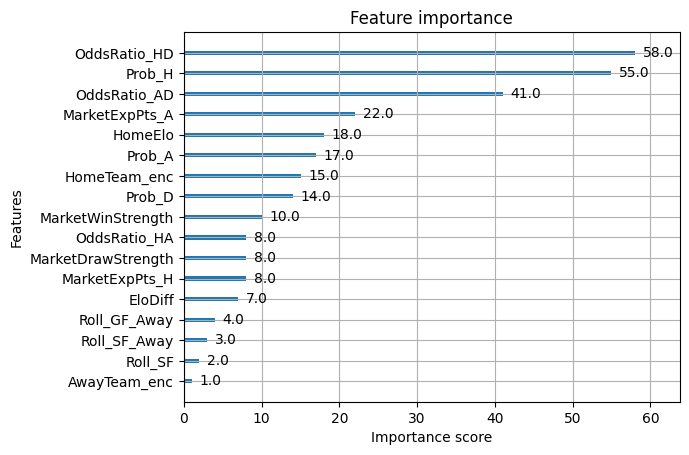

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(final_model, max_num_features=20)
plt.show()


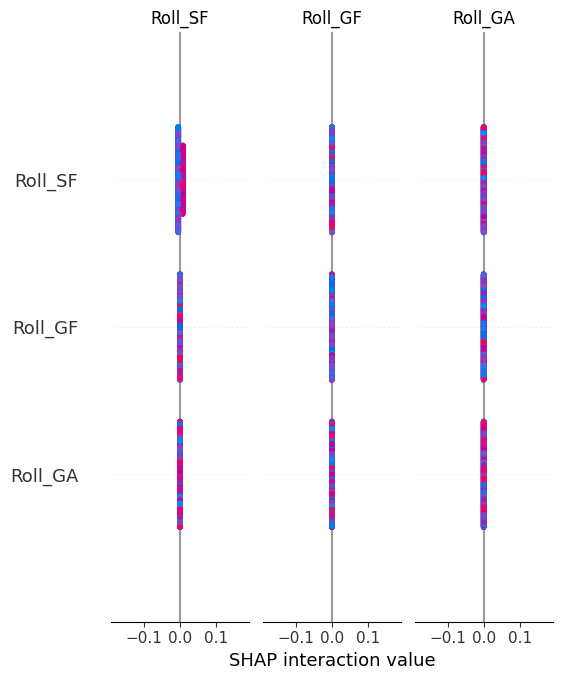

In [ ]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, feature_names=feature_list)


In [ ]:
feature_list_no_odds = [
    "HomeElo", "AwayElo", "EloDiff",

    "Roll_GF", "Roll_GA", "Roll_SF", "Roll_SA",
    "Roll_GF_Away", "Roll_GA_Away", "Roll_SF_Away", "Roll_SA_Away",

    "HomeTeam_enc", "AwayTeam_enc"
]


In [ ]:
from xgboost import XGBClassifier

model_no_odds = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    min_child_weight=5,
    gamma=3,
    random_state=42
)

X_no_odds = df_all[feature_list_no_odds]
y_no_odds = df_all["Target_enc"]

model_no_odds.fit(X_no_odds, y_no_odds)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3, ...)

In [ ]:
# ---------------------------------------------------------
# FIXED: Pull Elo from elo_table instead of df_all
# ---------------------------------------------------------

# 1. Get Elo values directly from elo_table
home_elo = elo_table[elo_table["Team"] == "Man United"]["FinalElo"].values[0]
away_elo = elo_table[elo_table["Team"] == "Man City"]["FinalElo"].values[0]

# 2. Still pull rolling stats from df_all (latest rows)
df_all = df_all.sort_values("Date")
latest_rows = df_all.groupby("Team").tail(1)

home_row = latest_rows[latest_rows["Team"] == "Man United"].iloc[0]
away_row = latest_rows[latest_rows["Team"] == "Man City"].iloc[0]

# 3. Build feature vector (no odds)
new_match_no_odds = {}

new_match_no_odds["HomeElo"] = home_elo
new_match_no_odds["AwayElo"] = away_elo
new_match_no_odds["EloDiff"] = home_elo - away_elo

new_match_no_odds["Roll_GF"] = home_row["Roll_GF"]
new_match_no_odds["Roll_GA"] = home_row["Roll_GA"]
new_match_no_odds["Roll_SF"] = home_row["Roll_SF"]
new_match_no_odds["Roll_SA"] = home_row["Roll_SA"]

new_match_no_odds["Roll_GF_Away"] = away_row["Roll_GF"]
new_match_no_odds["Roll_GA_Away"] = away_row["Roll_GA"]
new_match_no_odds["Roll_SF_Away"] = away_row["Roll_SF"]
new_match_no_odds["Roll_SA_Away"] = away_row["Roll_SA"]

new_match_no_odds["HomeTeam_enc"] = le_team.transform(["Man United"])[0]
new_match_no_odds["AwayTeam_enc"] = le_team.transform(["Man City"])[0]

# 4. Build dataframe
new_X_no_odds = pd.DataFrame([new_match_no_odds])[feature_list_no_odds]


In [ ]:
probs_no_odds = model_no_odds.predict_proba(new_X_no_odds)[0]

decoded = le_target.inverse_transform(model_no_odds.classes_)
prob_map = {cls: probs_no_odds[i] for i, cls in enumerate(decoded)}

print("Model B (No Odds) Prediction:")
print(f"P(Home Win) = {prob_map['H']:.3f}")
print(f"P(Draw)     = {prob_map['D']:.3f}")
print(f"P(Away Win) = {prob_map['A']:.3f}")


Model B (No Odds) Prediction:
P(Home Win) = 0.375
P(Draw)     = 0.266
P(Away Win) = 0.359


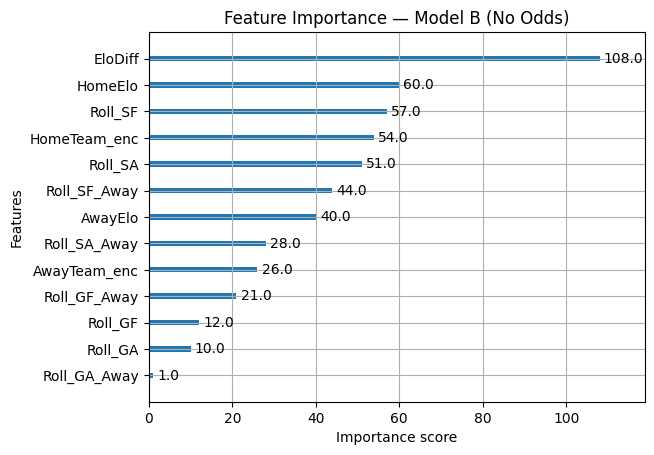

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model_no_odds, max_num_features=20)
plt.title("Feature Importance — Model B (No Odds)")
plt.show()


In [ ]:
decoded = le_target.inverse_transform(model_no_odds.classes_)
prob_map = {cls: probs_no_odds[i] for i, cls in enumerate(decoded)}

print(decoded)
print(prob_map)


['A' 'D' 'H']
{'A': np.float32(0.35923123), 'D': np.float32(0.2659425), 'H': np.float32(0.37482625)}


In [ ]:
print("HOME TEAM FEATURES (Man United)")
print({
    "HomeElo": elo_table[elo_table["Team"] == "Man United"]["FinalElo"].values[0],
    "Roll_GF": home_row["Roll_GF"],
    "Roll_GA": home_row["Roll_GA"],
    "Roll_SF": home_row["Roll_SF"],
    "Roll_SA": home_row["Roll_SA"]
})

print("\nAWAY TEAM FEATURES (Man City)")
print({
    "AwayElo": elo_table[elo_table["Team"] == "Man City"]["FinalElo"].values[0],
    "Roll_GF": away_row["Roll_GF"],
    "Roll_GA": away_row["Roll_GA"],
    "Roll_SF": away_row["Roll_SF"],
    "Roll_SA": away_row["Roll_SA"]
})


HOME TEAM FEATURES (Man United)
{'HomeElo': np.float64(1626.9598671462618), 'Roll_GF': np.float64(1.8), 'Roll_GA': np.float64(1.2), 'Roll_SF': np.float64(18.0), 'Roll_SA': np.float64(12.0)}

AWAY TEAM FEATURES (Man City)
{'AwayElo': np.float64(1714.260346562846), 'Roll_GF': np.float64(2.2), 'Roll_GA': np.float64(1.0), 'Roll_SF': np.float64(15.2), 'Roll_SA': np.float64(8.4)}


In [ ]:
probs_no_odds = model_no_odds.predict_proba(new_X_no_odds)[0]

decoded = le_target.inverse_transform(model_no_odds.classes_)
prob_map = {cls: probs_no_odds[i] for i, cls in enumerate(decoded)}

print("Model B (No Odds) Prediction:")
print(f"P(Home Win) = {prob_map['H']:.3f}")
print(f"P(Draw)     = {prob_map['D']:.3f}")
print(f"P(Away Win) = {prob_map['A']:.3f}")

Model B (No Odds) Prediction:
P(Home Win) = 0.375
P(Draw)     = 0.266
P(Away Win) = 0.359


In [ ]:
# Requirements: scikit-learn, xgboost, pandas, numpy
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import log_loss, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

# Ensure df_all is sorted by date (important for football data)
df_all = df_all.sort_values("Date").reset_index(drop=True)

# Football-only feature set
X = df_all[feature_list_no_odds]

# Encoded target (H/D/A → 0/1/2)
y = df_all["Target_enc"]


# 2) Train/validation split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3) Define XGBoost and Grid
xgb_clf = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=8
)

param_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 400],
    "max_depth": [3, 4],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0.0, 0.5],
    "reg_lambda": [1.0, 2.0],
    "gamma": [0, 1]
}

# 4) Scorer and CV
scorer = make_scorer(log_loss, greater_is_better=False, needs_proba=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5) GridSearchCV (coarse grid first)
grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    verbose=2,
    n_jobs=6,
    refit=True
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV logloss:", -grid.best_score_)

# 6) Evaluate on validation set
best = grid.best_estimator_
probs_val = best.predict_proba(X_val)
val_logloss = log_loss(y_val, probs_val)
print("Validation logloss:", val_logloss)

# 7) Permutation importance for feature selection
perm = permutation_importance(best, X_val, y_val, n_repeats=30, random_state=42, n_jobs=6, scoring='neg_log_loss')
imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(imp_df)

# 8) Optional: iterative feature removal (simple loop)
current_features = list(X.columns)
best_val = val_logloss
tolerance = 0.002

for feat in imp_df.sort_values("importance_mean", ascending=True)["feature"].tolist():
    trial_features = [f for f in current_features if f != feat]
    best.set_params(n_jobs=6)
    best.fit(X_train[trial_features], y_train)
    probs = best.predict_proba(X_val[trial_features])
    ll = log_loss(y_val, probs)
    if ll <= best_val + tolerance:
        # removal acceptable
        current_features = trial_features
        best_val = ll
        print(f"Removed {feat}, new val logloss {ll:.5f}")
    else:
        print(f"Keeping {feat}, removal increased logloss to {ll:.5f}")

print("Final feature set:", current_features)

# 9) Refit final model on full training data (train+val) with best params and final features
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

final_model_no_odds = XGBClassifier(**grid.best_params_, objective="multi:softprob", num_class=3, use_label_encoder=False, eval_metric="mlogloss", random_state=42, n_jobs=8)
final_model_no_odds.fit(X_full[current_features], y_full)

# 10) Save or use final_model_no_odds for predictions


Fitting 5 folds for each of 768 candidates, totalling 3840 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan

Best params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV logloss: nan
Validation logloss: 1.0157522941997053
         feature  importance_mean  importance_std
2        EloDiff         0.028506        0.008527
6        Roll_SA         0.011317        0.006586
7   Roll_GF_Away         0.009083        0.004327
9   Roll_SF_Away         0.005082        0.006296
12  AwayTeam_enc         0.004054        0.002772
10  Roll_SA_Away         0.003421        0.003768
11  HomeTeam_enc         0.001035        0.005136
4        Roll_GA         0.000544        0.001819
3        Roll_GF        -0.000587        0.001967
0        HomeElo        -0.000858        0.005879
1        AwayElo        -0.001552        0.005177
8   Roll_GA_Away        -0.002713        0.002264
5        Roll_SF        -0.003228        0.007090


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:01:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Removed Roll_SF, new val logloss 1.00708


...

Keeping Roll_GF_Away, removal increased logloss to 0.99797


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:01:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Keeping Roll_SA, removal increased logloss to 1.00546
Keeping EloDiff, removal increased logloss to 1.01628
Final feature set: ['EloDiff', 'Roll_SA', 'Roll_GF_Away', 'Roll_GA_Away', 'Roll_SA_Away', 'AwayTeam_enc']


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:01:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:01:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=8, num_class=3, ...)

In [ ]:
models["XGBoost"] = {
    "model": final_model_no_odds,
    "features": current_features
}


In [ ]:
models = {}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

# Sort data
df_all = df_all.sort_values("Date").reset_index(drop=True)

# Features and target
X = df_all[feature_list_no_odds]
y = df_all["Target_enc"]

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_val_scaled = scaler_lr.transform(X_val)

lr_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500
)

lr_model.fit(X_train_scaled, y_train)

probs_lr = lr_model.predict_proba(X_val_scaled)

print("LR Log Loss:", log_loss(y_val, probs_lr))
print("LR Accuracy:", accuracy_score(y_val, np.argmax(probs_lr, axis=1)))

models["Linear Regression"] = {
    "model": lr_model,
    "scaler": scaler_lr,
    "features": feature_list_no_odds
}

def predict_lr(new_X):
    X_scaled = models["Linear Regression"]["scaler"].transform(new_X)
    probs = models["Linear Regression"]["model"].predict_proba(X_scaled)[0]

    print("\nLogistic Regression Prediction:")
    print(f"P(Away Win) = {probs[0]:.3f}")
    print(f"P(Draw)     = {probs[1]:.3f}")
    print(f"P(Home Win) = {probs[2]:.3f}")

    return {
        "Away Win": probs[0],
        "Draw": probs[1],
        "Home Win": probs[2]
    }


LR Log Loss: 1.0238137906617502
LR Accuracy: 0.5096774193548387


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
def predict_lr(new_X):
    X_scaled = models["Linear Regression"]["scaler"].transform(new_X)
    probs = models["Linear Regression"]["model"].predict_proba(X_scaled)[0]
    return {
        "Away Win": probs[0],
        "Draw": probs[1],
        "Home Win": probs[2]
    }
predict_lr(new_X_no_odds)


{'Away Win': np.float64(0.33232382623662043),
 'Draw': np.float64(0.2511462170395193),
 'Home Win': np.float64(0.4165299567238603)}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score

# Sort data
df_all = df_all.sort_values("Date").reset_index(drop=True)

# Features and target
X = df_all[feature_list_no_odds]
y = df_all["Target_enc"]

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

probs_rf = rf_model.predict_proba(X_val)

print("Random Forest Log Loss:", log_loss(y_val, probs_rf))
print("Random Forest Accuracy:", accuracy_score(y_val, np.argmax(probs_rf, axis=1)))


Random Forest Log Loss: 1.025891888959849
Random Forest Accuracy: 0.5032258064516129


In [ ]:
print("\nSample predicted probabilities (Away, Draw, Home):")
for i in range(5):
    print(f"Match {i+1}: {probs_rf[i]}")

models["Random Forest"] = {
    "model": rf_model,
    "features": feature_list_no_odds
}



Sample predicted probabilities (Away, Draw, Home):
Match 1: [0.47333333 0.26333333 0.26333333]
Match 2: [0.15       0.38666667 0.46333333]
Match 3: [0.71333333 0.17       0.11666667]
Match 4: [0.30333333 0.4        0.29666667]
Match 5: [0.35666667 0.14666667 0.49666667]


In [ ]:
def predict_rf(new_X):
    probs = models["Random Forest"]["model"].predict_proba(new_X)[0]

    print("\nRandom Forest Prediction:")
    print(f"P(Away Win) = {probs[0]:.3f}")
    print(f"P(Draw)     = {probs[1]:.3f}")
    print(f"P(Home Win) = {probs[2]:.3f}")

    return {
        "Away Win": probs[0],
        "Draw": probs[1],
        "Home Win": probs[2]
    }

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="neg_log_loss",
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Params:", grid_rf.best_params_)
print("Best CV Log Loss:", -grid_rf.best_score_)



Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Log Loss: 1.0155287341792092


In [ ]:
rf_tuned = RandomForestClassifier(
    **grid_rf.best_params_,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

probs_rf_tuned = rf_tuned.predict_proba(X_val)

print("Tuned RF Log Loss:", log_loss(y_val, probs_rf_tuned))
print("Tuned RF Accuracy:", accuracy_score(y_val, np.argmax(probs_rf_tuned, axis=1)))



Tuned RF Log Loss: 1.0138675864173883
Tuned RF Accuracy: 0.4935483870967742


In [ ]:
models["Random Forest (Tuned)"] = {
    "model": rf_tuned,
    "features": feature_list_no_odds
}

def predict_rf_tuned(new_X):
    probs = models["Random Forest (Tuned)"]["model"].predict_proba(new_X)[0]

    print("\nTuned Random Forest Prediction:")
    print(f"P(Away Win) = {probs[0]:.3f}")
    print(f"P(Draw)     = {probs[1]:.3f}")
    print(f"P(Home Win) = {probs[2]:.3f}")

    return {
        "Away Win": probs[0],
        "Draw": probs[1],
        "Home Win": probs[2]
    }


In [ ]:
# Linear Regression
probs_lr_val = models["Linear Regression"]["model"].predict_proba(
    models["Linear Regression"]["scaler"].transform(X_val)
)

# Random Forest
probs_rf_val = models["Random Forest"]["model"].predict_proba(X_val)

# Tuned Random Forest
probs_rf_tuned_val = models["Random Forest (Tuned)"]["model"].predict_proba(X_val)

# XGBoost (No Odds Model)
probs_xgb_val = models["XGBoost"]["model"].predict_proba(X_val[models["XGBoost"]["features"]])



In [ ]:
import numpy as np
from sklearn.metrics import log_loss

best_loss = 999
best_weights = None

# Try weights in steps of 0.1
weights = np.arange(0, 1.1, 0.1)

for w1 in weights:
    for w2 in weights:
        for w3 in weights:
            for w4 in weights:
                if abs((w1 + w2 + w3 + w4) - 1.0) < 1e-6:

                    ensemble_probs = (
                        w1 * probs_lr_val +
                        w2 * probs_rf_val +
                        w3 * probs_rf_tuned_val +
                        w4 * probs_xgb_val
                    )

                    loss = log_loss(y_val, ensemble_probs)

                    if loss < best_loss:
                        best_loss = loss
                        best_weights = (w1, w2, w3, w4)

print("Best Ensemble Weights:", best_weights)
print("Best Ensemble Log Loss:", best_loss)


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T

Best Ensemble Weights: (np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0))
Best Ensemble Log Loss: 0.8934890537471984


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [ ]:
models["Ensemble"] = {
    "weights": best_weights,
    "models": {
        "LR": models["Linear Regression"],
        "RF": models["Random Forest"],
        "RF_tuned": models["Random Forest (Tuned)"],
        "XGB": xgb_clf
    }
}


In [ ]:
def predict_ensemble(new_X):
    w1, w2, w3, w4 = models["Ensemble"]["weights"]

    # LR
    X_scaled = models["Linear Regression"]["scaler"].transform(new_X)
    p_lr = models["Linear Regression"]["model"].predict_proba(X_scaled)[0]

    # RF
    p_rf = models["Random Forest"]["model"].predict_proba(new_X)[0]

    # RF tuned
    p_rf_tuned = models["Random Forest (Tuned)"]["model"].predict_proba(new_X)[0]

    # XGB
    p_xgb = models["Ensemble"]["models"]["XGB"].predict_proba(new_X)[0]

    # Weighted ensemble
    p_final = (
        w1 * p_lr +
        w2 * p_rf +
        w3 * p_rf_tuned +
        w4 * p_xgb
    )

    print("\nEnsemble Prediction:")
    print(f"P(Away Win) = {p_final[0]:.3f}")
    print(f"P(Draw)     = {p_final[1]:.3f}")
    print(f"P(Home Win) = {p_final[2]:.3f}")

    return {
        "Away Win": p_final[0],
        "Draw": p_final[1],
        "Home Win": p_final[2]
    }


In [ ]:
import joblib

joblib.dump(models["Linear Regression"]["model"], "linear_regression.pkl")
joblib.dump(models["Linear Regression"]["scaler"], "lr_scaler.pkl")

joblib.dump(models["Random Forest"]["model"], "random_forest.pkl")

joblib.dump(models["Random Forest (Tuned)"]["model"], "random_forest_tuned.pkl")

joblib.dump(final_model_no_odds, "xgb_final_model.pkl")

joblib.dump(current_features, "xgb_final_features.pkl")

import numpy as np
np.save("ensemble_weights.npy", models["Ensemble"]["weights"])

joblib.dump(feature_list_no_odds, "feature_list.pkl")




['feature_list.pkl']

In [ ]:
import joblib
import numpy as np

models = {}

# 1) Load XGBoost FIRST
final_model_no_odds = joblib.load("xgb_final_model.pkl")
current_features = joblib.load("xgb_final_features.pkl")

models["XGBoost"] = {
    "model": final_model_no_odds,
    "features": current_features
}

# 2) Load the other models
models["Linear Regression"] = {
    "model": joblib.load("linear_regression.pkl"),
    "scaler": joblib.load("lr_scaler.pkl"),
    "features": joblib.load("feature_list.pkl")
}

models["Random Forest"] = {
    "model": joblib.load("random_forest.pkl"),
    "features": joblib.load("feature_list.pkl")
}

models["Random Forest (Tuned)"] = {
    "model": joblib.load("random_forest_tuned.pkl"),
    "features": joblib.load("feature_list.pkl")
}

# 3) Load ensemble weights LAST
models["Ensemble"] = {
    "weights": np.load("ensemble_weights.npy"),
    "models": {
        "LR": models["Linear Regression"],
        "RF": models["Random Forest"],
        "RF_tuned": models["Random Forest (Tuned)"],
        "XGB": models["XGBoost"]
    }
}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

joblib.dump(final_model_no_odds, "/content/drive/MyDrive/xgb_final_model.pkl")
joblib.dump(current_features, "/content/drive/MyDrive/xgb_final_features.pkl")

joblib.dump(models["Linear Regression"]["model"], "/content/drive/MyDrive/linear_regression.pkl")
joblib.dump(models["Linear Regression"]["scaler"], "/content/drive/MyDrive/lr_scaler.pkl")

joblib.dump(models["Random Forest"]["model"], "/content/drive/MyDrive/random_forest.pkl")

joblib.dump(models["Random Forest (Tuned)"]["model"], "/content/drive/MyDrive/random_forest_tuned.pkl")

np.save("/content/drive/MyDrive/ensemble_weights.npy", models["Ensemble"]["weights"])

joblib.dump(feature_list_no_odds, "/content/drive/MyDrive/feature_list.pkl")


Mounted at /content/drive


['/content/drive/MyDrive/feature_list.pkl']

In [ ]:
import pandas as pd
from sklearn.metrics import log_loss, accuracy_score

results = []

# --- Linear Regression (Logistic Regression) ---
lr_model = models["Linear Regression"]["model"]
lr_scaler = models["Linear Regression"]["scaler"]
lr_features = models["Linear Regression"]["features"]

probs_lr = lr_model.predict_proba(lr_scaler.transform(X_val[lr_features]))
acc_lr = accuracy_score(y_val, probs_lr.argmax(axis=1))
ll_lr = log_loss(y_val, probs_lr)

results.append({
    "Model": "Logistic Regression",
    "Log Loss": ll_lr,
    "Accuracy": acc_lr
})


# --- Random Forest ---
rf_model = models["Random Forest"]["model"]
rf_features = models["Random Forest"]["features"]

probs_rf = rf_model.predict_proba(X_val[rf_features])
acc_rf = accuracy_score(y_val, probs_rf.argmax(axis=1))
ll_rf = log_loss(y_val, probs_rf)

results.append({
    "Model": "Random Forest",
    "Log Loss": ll_rf,
    "Accuracy": acc_rf
})


# --- Tuned Random Forest ---
rf_tuned_model = models["Random Forest (Tuned)"]["model"]
rf_tuned_features = models["Random Forest (Tuned)"]["features"]

probs_rf_tuned = rf_tuned_model.predict_proba(X_val[rf_tuned_features])
acc_rf_tuned = accuracy_score(y_val, probs_rf_tuned.argmax(axis=1))
ll_rf_tuned = log_loss(y_val, probs_rf_tuned)

results.append({
    "Model": "Random Forest (Tuned)",
    "Log Loss": ll_rf_tuned,
    "Accuracy": acc_rf_tuned
})


# --- XGBoost ---
xgb_model = models["XGBoost"]["model"]
xgb_features = models["XGBoost"]["features"]

probs_xgb = xgb_model.predict_proba(X_val[xgb_features])
acc_xgb = accuracy_score(y_val, probs_xgb.argmax(axis=1))
ll_xgb = log_loss(y_val, probs_xgb)

results.append({
    "Model": "XGBoost (No Odds)",
    "Log Loss": ll_xgb,
    "Accuracy": acc_xgb
})


# --- Ensemble ---
w1, w2, w3, w4 = models["Ensemble"]["weights"]

ensemble_probs = (
    w1 * probs_lr +
    w2 * probs_rf +
    w3 * probs_rf_tuned +
    w4 * probs_xgb
)

acc_ens = accuracy_score(y_val, ensemble_probs.argmax(axis=1))
ll_ens = log_loss(y_val, ensemble_probs)

results.append({
    "Model": "Ensemble",
    "Log Loss": ll_ens,
    "Accuracy": acc_ens
})


# --- Build comparison table ---
comparison_df = pd.DataFrame(results).sort_values("Log Loss")
print(comparison_df)


                   Model  Log Loss  Accuracy
3      XGBoost (No Odds)  0.893489  0.590323
4               Ensemble  0.893489  0.590323
0    Logistic Regression  0.999020  0.541935
2  Random Forest (Tuned)  1.013868  0.493548
1          Random Forest  1.025892  0.503226


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


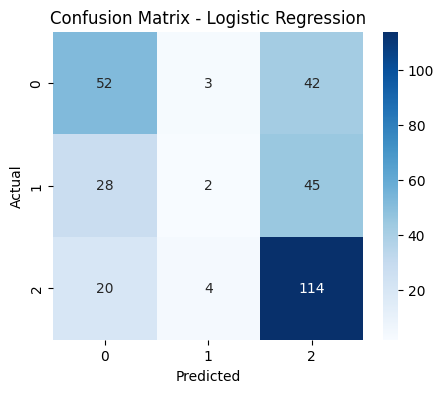

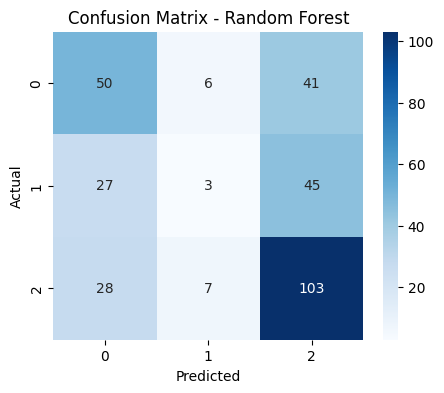

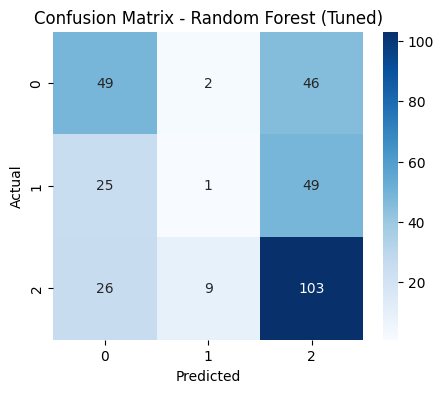

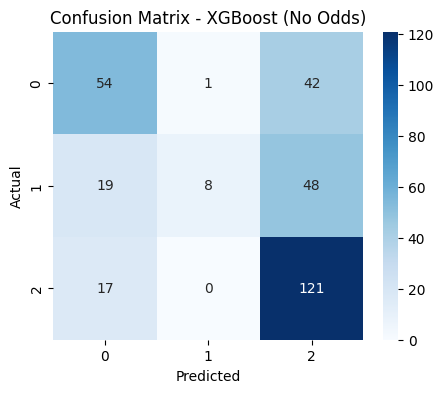

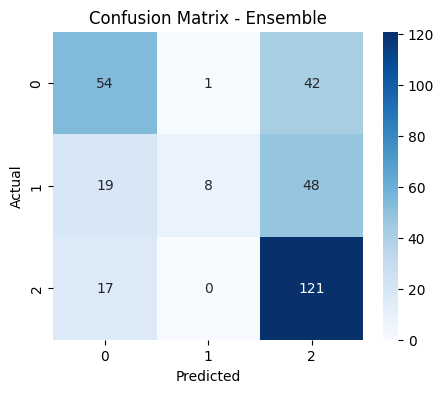

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# -----------------------------
# 1) Logistic Regression
# -----------------------------
lr_model = models["Linear Regression"]["model"]
lr_scaler = models["Linear Regression"]["scaler"]
lr_features = models["Linear Regression"]["features"]

probs_lr = lr_model.predict_proba(lr_scaler.transform(X_val[lr_features]))
pred_lr = probs_lr.argmax(axis=1)

plot_cm(y_val, pred_lr, "Confusion Matrix - Logistic Regression")


# -----------------------------
# 2) Random Forest
# -----------------------------
rf_model = models["Random Forest"]["model"]
rf_features = models["Random Forest"]["features"]

probs_rf = rf_model.predict_proba(X_val[rf_features])
pred_rf = probs_rf.argmax(axis=1)

plot_cm(y_val, pred_rf, "Confusion Matrix - Random Forest")


# -----------------------------
# 3) Tuned Random Forest
# -----------------------------
rf_tuned_model = models["Random Forest (Tuned)"]["model"]
rf_tuned_features = models["Random Forest (Tuned)"]["features"]

probs_rf_tuned = rf_tuned_model.predict_proba(X_val[rf_tuned_features])
pred_rf_tuned = probs_rf_tuned.argmax(axis=1)

plot_cm(y_val, pred_rf_tuned, "Confusion Matrix - Random Forest (Tuned)")


# -----------------------------
# 4) XGBoost
# -----------------------------
xgb_model = models["XGBoost"]["model"]
xgb_features = models["XGBoost"]["features"]

probs_xgb = xgb_model.predict_proba(X_val[xgb_features])
pred_xgb = probs_xgb.argmax(axis=1)

plot_cm(y_val, pred_xgb, "Confusion Matrix - XGBoost (No Odds)")


# -----------------------------
# 5) Ensemble
# -----------------------------
w1, w2, w3, w4 = models["Ensemble"]["weights"]

ensemble_probs = (
    w1 * probs_lr +
    w2 * probs_rf +
    w3 * probs_rf_tuned +
    w4 * probs_xgb
)

pred_ens = ensemble_probs.argmax(axis=1)

plot_cm(y_val, pred_ens, "Confusion Matrix - Ensemble")


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# -----------------------------
# Build unified feature row
# -----------------------------
def build_features(team_home, team_away, df_all, all_features):
    home_rows = df_all[df_all["HomeTeam"] == team_home]
    away_rows = df_all[df_all["AwayTeam"] == team_away]

    if len(home_rows) == 0:
        raise ValueError(f"No data found for home team: {team_home}")
    if len(away_rows) == 0:
        raise ValueError(f"No data found for away team: {team_away}")

    home_row = home_rows.iloc[-1]
    away_row = away_rows.iloc[-1]

    combined = pd.DataFrame([home_row, away_row]).mean(numeric_only=True)
    combined = combined.to_frame().T

    for col in all_features:
        if col not in combined.columns:
            combined[col] = 0.0

    combined = combined[all_features]
    return combined

# -----------------------------
# Collect ALL features needed
# -----------------------------
all_features = sorted(
    set(models["Linear Regression"]["features"])
    | set(models["Random Forest"]["features"])
    | set(models["Random Forest (Tuned)"]["features"])
    | set(models["XGBoost"]["features"])
)

# -----------------------------
# Format output nicely
# -----------------------------
def format_output(p_final):
    df = pd.DataFrame({
        "Outcome": ["Away Win", "Draw", "Home Win"],
        "Probability": [p_final[0], p_final[1], p_final[2]]
    })
    return df

# -----------------------------
# Prediction function
# -----------------------------
def predict_match(team_home, team_away):
    try:
        X_new = build_features(team_home, team_away, df_all, all_features)

        p_lr = models["Linear Regression"]["model"].predict_proba(
            models["Linear Regression"]["scaler"].transform(X_new[models["Linear Regression"]["features"]])
        )[0]

        p_rf = models["Random Forest"]["model"].predict_proba(
            X_new[models["Random Forest"]["features"]]
        )[0]

        p_rf_tuned = models["Random Forest (Tuned)"]["model"].predict_proba(
            X_new[models["Random Forest (Tuned)"]["features"]]
        )[0]

        p_xgb = models["XGBoost"]["model"].predict_proba(
            X_new[models["XGBoost"]["features"]]
        )[0]

        w1, w2, w3, w4 = models["Ensemble"]["weights"]
        p_final = w1*p_lr + w2*p_rf + w3*p_rf_tuned + w4*p_xgb

        return format_output(p_final)

    except Exception as e:
        return pd.DataFrame({"Error": [str(e)]})

# -----------------------------
# Dashboard UI
# -----------------------------
teams = sorted(df_all["HomeTeam"].unique())

with gr.Blocks() as demo:
    gr.Markdown("<h1 style='text-align:center;'>⚽ Football Prediction Dashboard</h1>")
    gr.Markdown("<h3 style='text-align:center;'>AI Ensemble Model • Match Outcome Probabilities</h3>")

    with gr.Row():
        home_team = gr.Dropdown(choices=teams, label="Home Team")
        away_team = gr.Dropdown(choices=teams, label="Away Team")

    predict_btn = gr.Button("Predict Match")

    output_table = gr.Dataframe(label="Match Probabilities", headers=["Outcome", "Probability"])
    output_plot = gr.BarPlot(
        label="Probability Chart",
        x="Outcome",
        y="Probability",
        color="Outcome"
    )

    def run_and_plot(home, away):
        df = predict_match(home, away)
        return df, df

    predict_btn.click(
        fn=run_and_plot,
        inputs=[home_team, away_team],
        outputs=[output_table, output_plot]
    )

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3d58e71f65a6cd29f8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.3 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import altair as alt

st.set_page_config(page_title="Football Prediction Dashboard", layout="centered")

# -----------------------------
# Unified feature builder
# -----------------------------
def build_features(team_home, team_away, df_all, all_features):
    home_rows = df_all[df_all["HomeTeam"] == team_home]
    away_rows = df_all[df_all["AwayTeam"] == team_away]

    if len(home_rows) == 0:
        raise ValueError(f"No data found for home team: {team_home}")
    if len(away_rows) == 0:
        raise ValueError(f"No data found for away team: {team_away}")

    home_row = home_rows.iloc[-1]
    away_row = away_rows.iloc[-1]

    combined = pd.DataFrame([home_row, away_row]).mean(numeric_only=True)
    combined = combined.to_frame().T

    for col in all_features:
        if col not in combined.columns:
            combined[col] = 0.0

    combined = combined[all_features]
    return combined

# -----------------------------
# Build master feature list
# -----------------------------
all_features = sorted(
    set(models["Linear Regression"]["features"])
    | set(models["Random Forest"]["features"])
    | set(models["Random Forest (Tuned)"]["features"])
    | set(models["XGBoost"]["features"])
)

# -----------------------------
# Prediction logic
# -----------------------------
def predict_probabilities(team_home, team_away):
    X_new = build_features(team_home, team_away, df_all, all_features)

    p_lr = models["Linear Regression"]["model"].predict_proba(
        models["Linear Regression"]["scaler"].transform(X_new[models["Linear Regression"]["features"]])
    )[0]

    p_rf = models["Random Forest"]["model"].predict_proba(
        X_new[models["Random Forest"]["features"]]
    )[0]

    p_rf_tuned = models["Random Forest (Tuned)"]["model"].predict_proba(
        X_new[models["Random Forest (Tuned)"]["features"]]
    )[0]

    p_xgb = models["XGBoost"]["model"].predict_proba(
        X_new[models["XGBoost"]["features"]]
    )[0]

    w1, w2, w3, w4 = models["Ensemble"]["weights"]
    p_final = w1*p_lr + w2*p_rf + w3*p_rf_tuned + w4*p_xgb

    df_probs = pd.DataFrame({
        "Outcome": ["Home Win", "Draw", "Away Win"],
        "Probability": [float(p_final[2]), float(p_final[1]), float(p_final[0])]
    })

    return df_probs

# -----------------------------
# Streamlit UI
# -----------------------------
st.title("⚽ Football Prediction Dashboard")
st.markdown("Select two teams to generate ensemble predictions.")

teams = sorted(df_all["HomeTeam"].unique())

col1, col2 = st.columns(2)
with col1:
    home_team = st.selectbox("Home Team", teams)
with col2:
    away_team = st.selectbox("Away Team", teams)

if st.button("Predict Match"):
    try:
        df_probs = predict_probabilities(home_team, away_team)

        df_display = df_probs.copy()
        df_display["Probability"] = (df_display["Probability"] * 100).round(2).astype(str) + " %"

        st.subheader("Predicted Probabilities")
        st.table(df_display.set_index("Outcome"))

        chart = alt.Chart(df_probs).mark_bar(size=50).encode(
            x=alt.X("Outcome:N", sort=["Home Win", "Draw", "Away Win"]),
            y=alt.Y("Probability:Q", scale=alt.Scale(domain=[0, 1])),
            color=alt.Color("Outcome:N")
        ).properties(width=600, height=300)

        text = chart.mark_text(
            dy=-10,
            color="black",
            size=14
        ).encode(
            text=alt.Text("Probability:Q", format=".2%")
        )

        st.altair_chart(chart + text, use_container_width=True)

    except Exception as e:
        st.error(f"Prediction error: {e}")


Writing app.py


In [ ]:
from google.colab import files
files.download('app.py')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_all.to_csv("df_all.csv", index=False)
from google.colab import files
files.download("df_all.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
np.save("ensemble_weights.npy", models["Ensemble"]["weights"])
files.download("ensemble_weights.npy")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(models["Linear Regression"]["model"], "/content/drive/MyDrive/linear_regression.pkl")
joblib.dump(models["Linear Regression"]["scaler"], "/content/drive/MyDrive/lr_scaler.pkl")

['/content/drive/MyDrive/lr_scaler.pkl']

In [ ]:
import pickle

with open("linear_regression.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("lr_scaler.pkl", "wb") as f:
    pickle.dump(lr_scaler, f)


In [ ]:
import sklearn
print("Colab sklearn version:", sklearn.__version__)



Colab sklearn version: 1.6.1


In [ ]:
import sys
sys.version

'3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]'